# Compare finished turbulence runs

Every statistic on one figure per section, all runs overlaid, **data always in black**, one fixed colour per run.
Plotting code lives in `run_comparison.py`; this notebook only picks the runs.

Needs, per run, `saved_results/{samples,sampling_times}/<config>.pt` (and `aux_moments/` for the moment-matching section).
The pull command for anything missing is printed by the loading cell.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
from run_comparison import *

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.3g}'.format)

## Runs to compare
`{display name: --label}`. Order fixes the colours.

In [12]:
RUNS = {
    'full s2 r1e-2':          'lamtune_full_n1_8500',
    'full s3 r1e-4':          'long_full_sched3_reg1e-4',
    'full s2 r1e-4':          'long_full_sched2_reg1e-4',
    'full s3 r1e-2':          'long_full_sched3_reg1e-2',
    'noL2lowpass':            'long_noL2lowpass_sched3_reg1e-4',
    'noScalarMorlet':         'long_noScalarMorlet_sched3_reg1e-4',
    #'noL2lowpass+noMorlet':   'long_noL2lowpass_noScalarMorlet_sched3_reg1e-4',
}
SEED = 900
THRESHOLD = 1e-8        # same as --moment_threshold

runs, missing = load_runs(RUNS, seed=SEED)
for k, r in runs.items():
    print(f"{k:24s} {tuple(r['xt'].shape)}  aux={'barphi_e' in r}  {r['runtime_h']:.1f} h")
if missing:
    print('\nMissing locally:', missing, '\nPull with (run it yourself):\n')
    print(pull_commands(missing))

full s2 r1e-2            (8500, 256)  aux=True  17.8 h
full s3 r1e-4            (8500, 256)  aux=True  17.0 h
full s2 r1e-4            (8500, 256)  aux=True  17.6 h
full s3 r1e-2            (8500, 256)  aux=True  17.0 h
noL2lowpass              (8500, 256)  aux=True  17.0 h
noScalarMorlet           (8500, 256)  aux=True  16.2 h


## Reference data and statistics
`x1` is rebuilt from the first run's `config.json` exactly as `run_SDE.py` does (all runs here share the data settings; the check below fails otherwise).

In [13]:
cfg0 = next(iter(runs.values()))['cfg']
keys = ('n1', 'subseries_len', 'target_len')
assert all(tuple(r['cfg'][k] for k in keys) == tuple(cfg0[k] for k in keys) for r in runs.values()), \
    'runs use different reference data'
x1 = reference_data(cfg0)
print('x1', tuple(x1.shape))

S_ref = compute_stats(x1)
S_runs = {k: compute_stats(r['xt']) for k, r in runs.items()}

x1 (8500, 256)


## Summary
Ratios are gen / data (1 = perfect). `mm_*` = moment matching at the final step; `mm_n_above_1` = moments with rel. error > 1. `spec_logrms` = RMS of log spectrum ratio. KS = Kolmogorov–Smirnov distance to the data.

In [14]:
ks = wavelet_ks(S_ref, S_runs)
# noise floor: the same data, a different random subset of series for the wavelet histograms
ks_floor = wavelet_ks(S_ref, {'data': compute_stats(x1, seed=1)}).loc['data'].max()
print(f'wavelet KS noise floor (data vs data): {ks_floor:.3f}')
summary_table(S_ref, S_runs, runs, THRESHOLD, ks=ks)

wavelet KS noise floor (data vs data): 0.036


,reg,sched,n_terms,nt,n1,runtime_h,mm_final_mean,mm_final_p90,mm_n_above_1,S2_ratio_tau1,flat4_ratio_tau1,flat6_ratio_tau1,skew_tau1 (data -0.028),spec_logrms,marg_KS,wav_KS_max
full s2 r1e-2,0.01,2,7,4e+04,8.5e+03,17.8,0.266,1.24,24,5.43,0.121,0.0146,0.00592,5.44,0.0144,0.986
full s3 r1e-4,0.0001,3,7,4e+04,8.5e+03,17,0.332,1.53,32,8.05,0.122,0.0158,0.00768,5.79,0.0147,0.989
full s2 r1e-4,0.0001,2,7,4e+04,8.5e+03,17.6,0.339,1.54,29,8.17,0.114,0.0106,0.000253,5.81,0.0143,0.989
full s3 r1e-2,0.01,3,7,4e+04,8.5e+03,17,0.0317,0.0252,1,0.964,0.99,0.964,0.13,1.07,0.0148,0.738
noL2lowpass,0.0001,3,6,4e+04,8.5e+03,17,0.36,1.83,32,8.17,0.118,0.0119,0.00197,5.81,0.0153,0.99
noScalarMorlet,0.0001,3,6,4e+04,8.5e+03,16.2,0.417,1.93,35,16.3,0.0853,0.0052,-0.00544,6.18,0.0153,0.993


## Time series

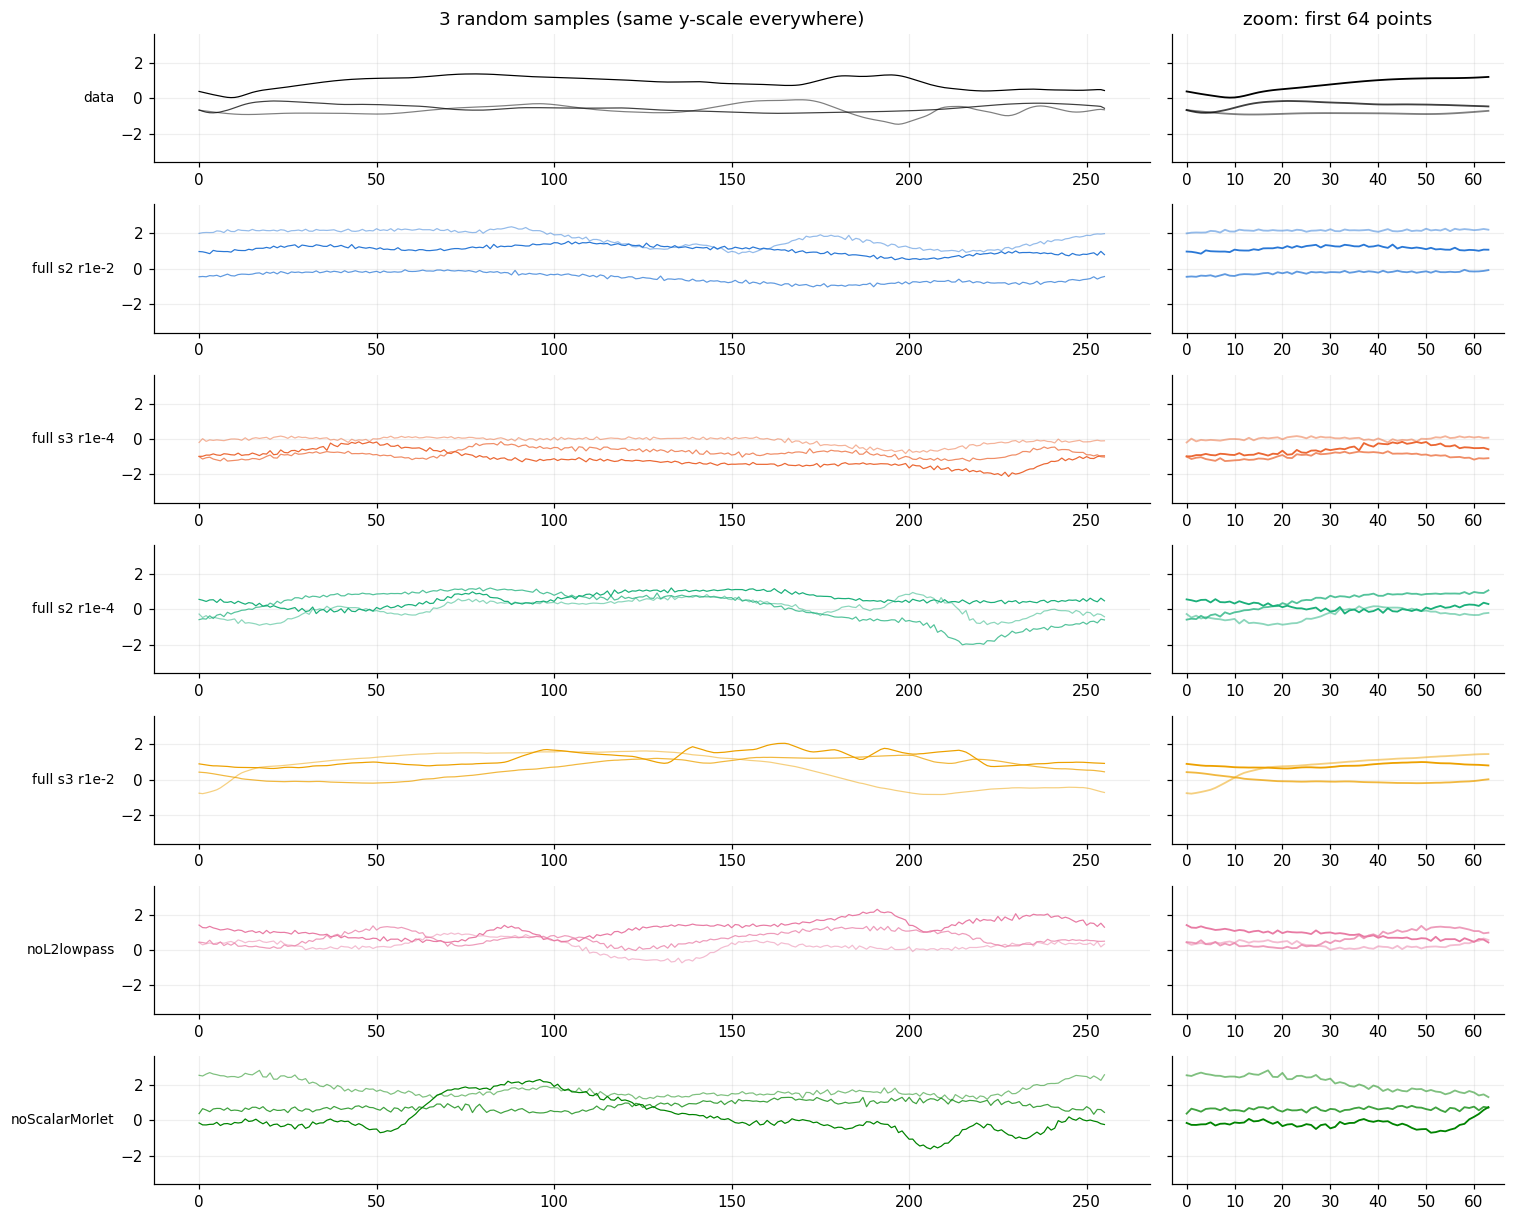

In [15]:
plot_time_series(x1, runs, n=3, zoom=64)

## Marginal PDF

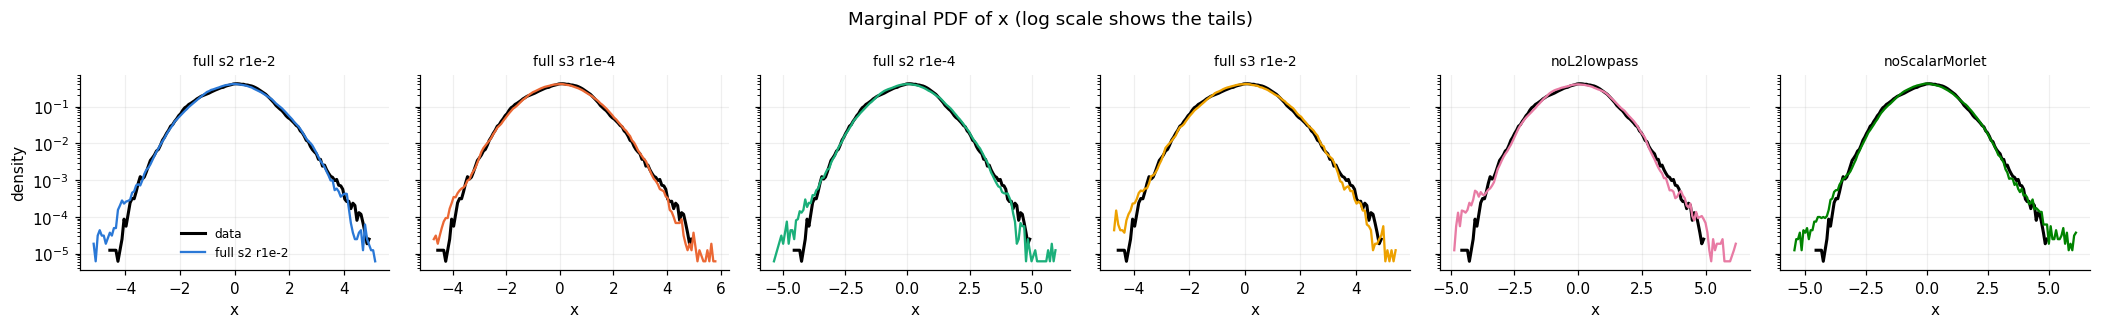

In [16]:
plot_marginals(S_ref, S_runs)

## Power spectrum

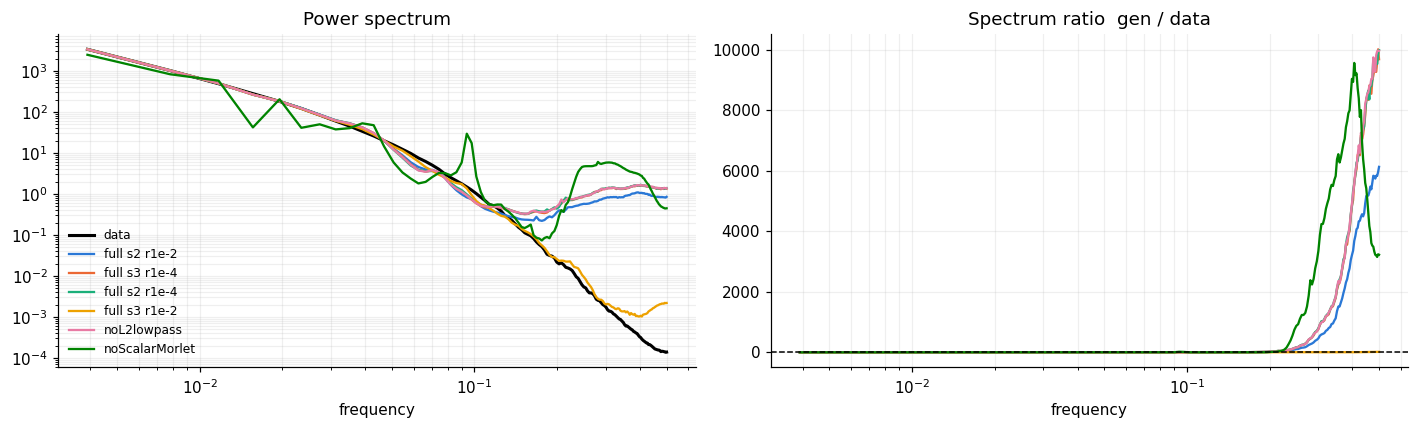

In [17]:
plot_spectra(S_ref, S_runs)

## Structure functions, flatness, skewness

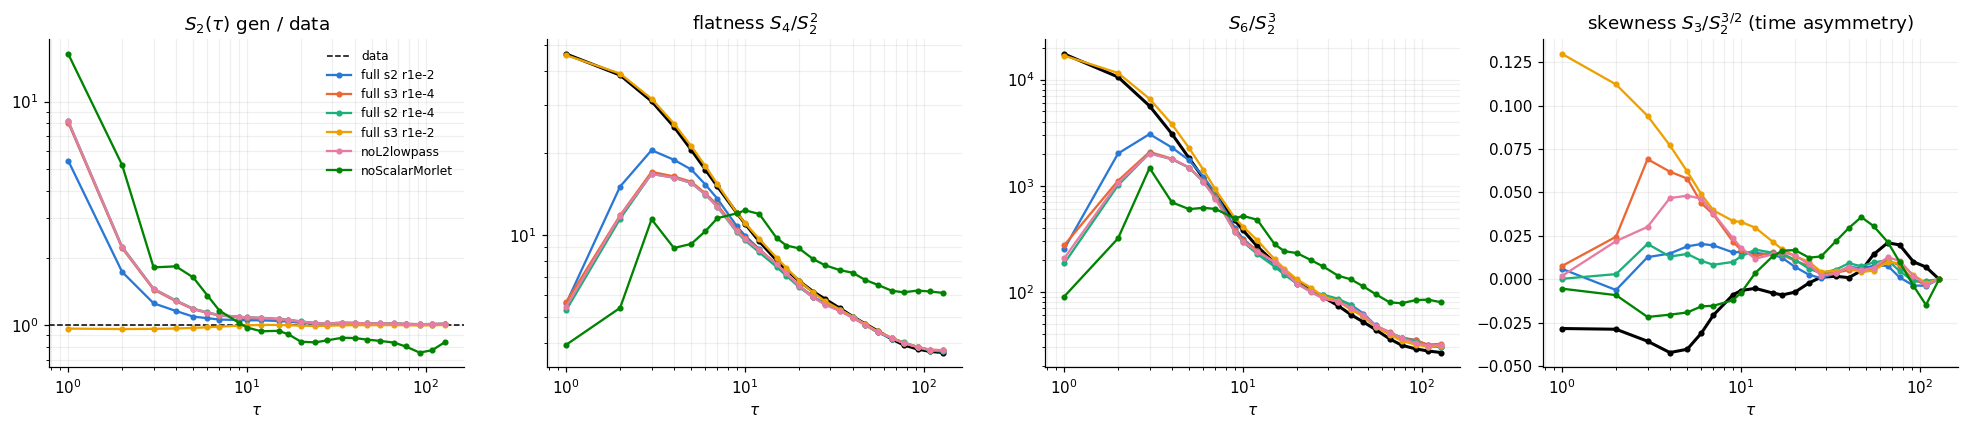

In [18]:
plot_structure(S_ref, S_runs)

## Increment PDFs

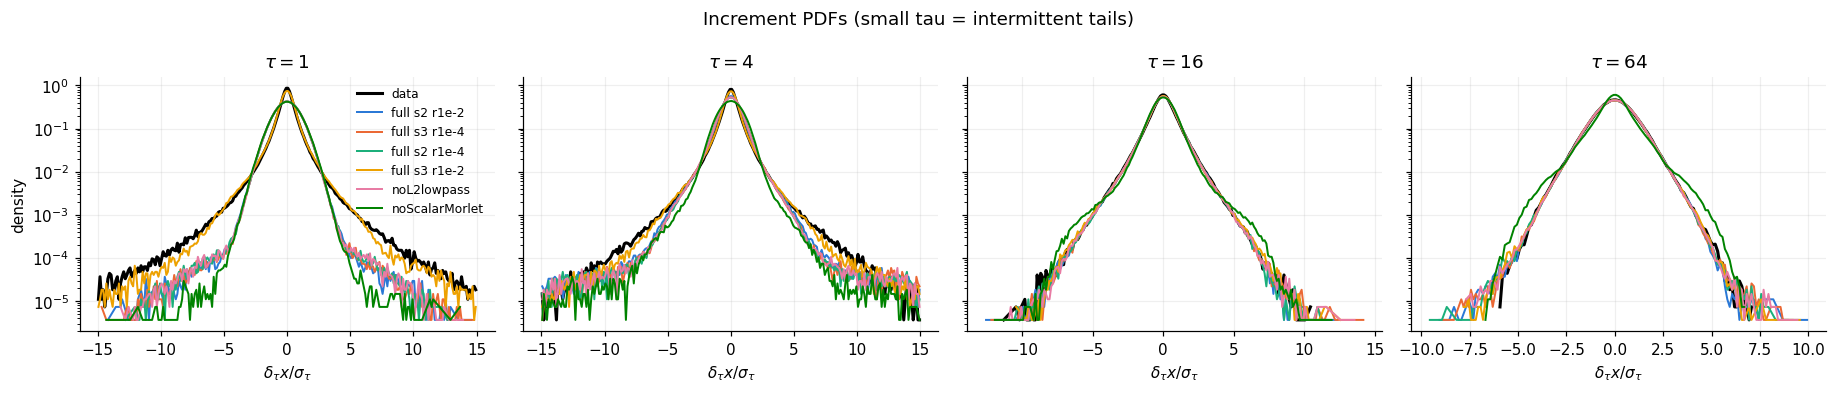

In [19]:
plot_increment_pdfs(S_ref, S_runs)

## Wavelet-coefficient histograms

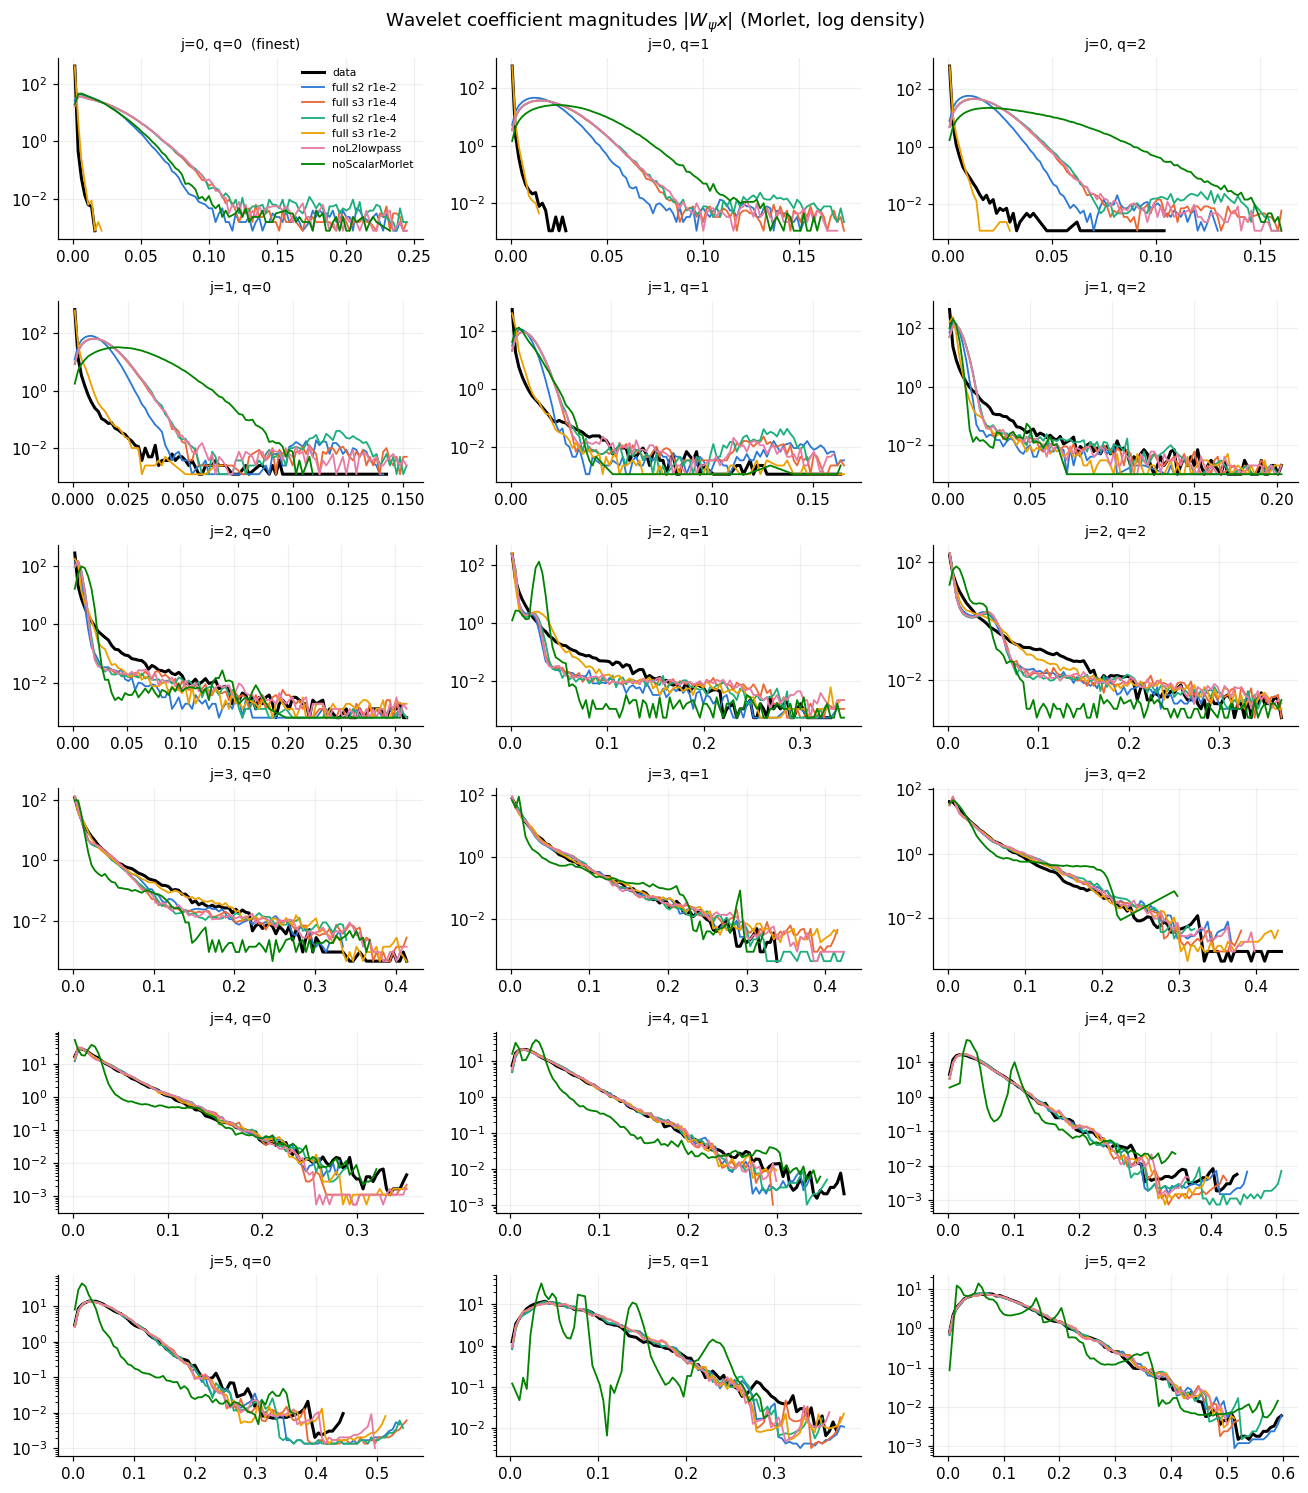

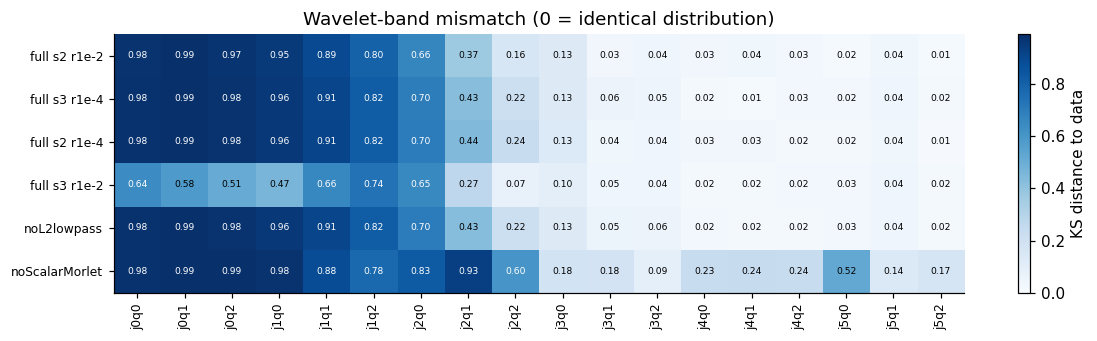

In [20]:
ks = plot_wavelet_hists(S_ref, S_runs)

## Moment matching
Runs with different potential sets have different moment sets, so compare the ablations here only qualitatively.

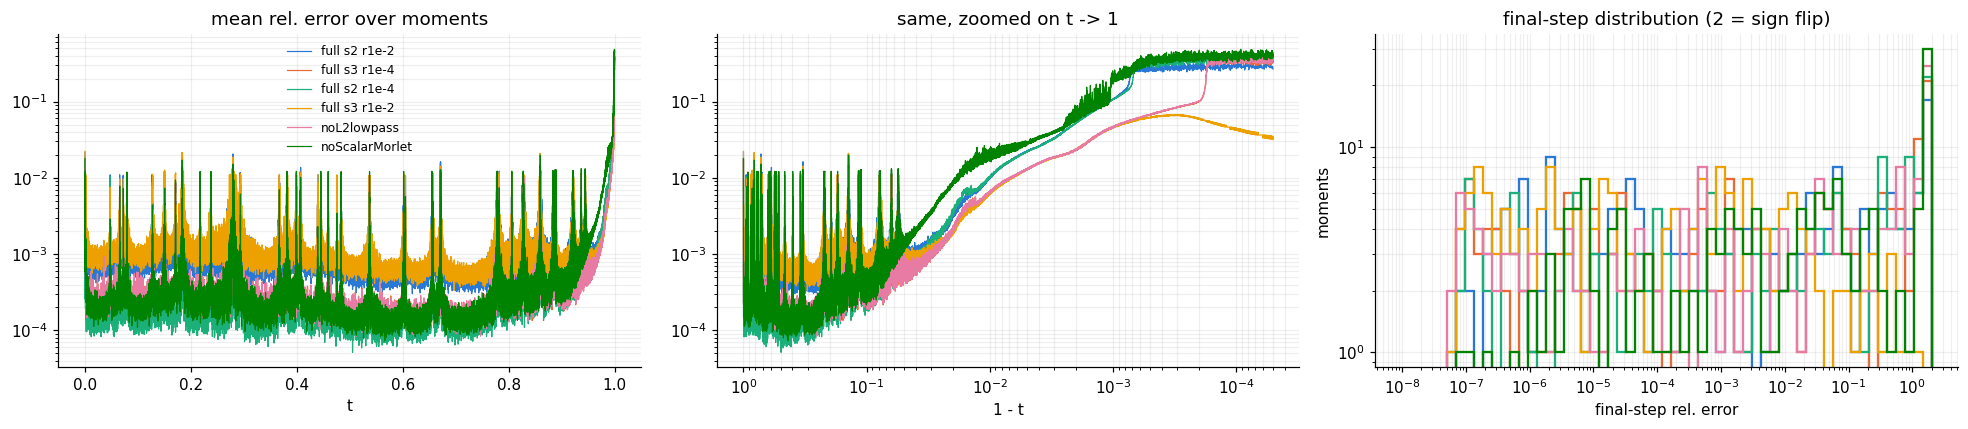

In [21]:
plot_moment_matching(runs, THRESHOLD)

## θ check: step-size instability or θ blow-up?
Shared $1-t$ axis. If the corrector actually applied, $\|\theta\|\,h\,\sigma^2$ (panel 4), spikes at the moment-error jump while $\|\theta\|$ (panel 3) is smooth, the step is too large for the drift (explicit-step instability). If $\|\theta\|$ itself grows or spikes there, the Gram solve is ill-conditioned (the ridge's job).
The printed component indices are rows of θ (after filter deduplication), not the moment indices of `compare_moment_matching.py --top`.

In [ ]:
plot_theta_check(runs, sigma=cfg0['sigma'], threshold=THRESHOLD, top=8, window=1e-3)